# SV & indel-SNP tagging (corrected) — arch3 panel vs GrENE-Net short-read SNPs

**Replaces** `sv_snp_ld_tagging.ipynb` / `build_sv_snp_ld.py`, which had two bugs
found while reviewing its plots:

1. **Missingness silently coded as REF.** The original loader only used
   `var_pa` (ALT-carrier), never `var_called` (the called mask) -- so a
   missing genotype and a true REF call were indistinguishable, for both the
   anchor (SV/indel) and the candidate SNP. Panel SV records have mean
   missingness of 26% (60/231 founders on average; median 41/231 &asymp; 18%)
   (`panel_stats_arch3.ipynb` &sect;5 -- note: an earlier draft of this note
   misquoted that section's mean *count* of missing founders, 60, as "~60%
   missing"; corrected here). Missingness is strongly cohort-correlated
   (long-read vs short-read), so jointly-missing founders could inflate
   apparent agreement if left unmasked.
2. **No MAC floor.** 53.5% of SVs are singletons (MAC=1) -- a singleton
   anchor can register a spurious r&sup2;=1 "tag" against any other marker
   private to the exact same one founder, a small-N coincidence, not real LD.

Confirmed empirically that the GrENE-Net short-read VCF has **zero missing
genotypes** (sampled ~2M GT calls), so only the panel (arch3) side needed
masking. Fixed in `analysis/grenenet_gea/build_tagging_masked.py`: proper
pairwise-complete masked r&sup2; (vectorized via matrix-vector products, not a
per-SNP loop) + a configurable MAC floor (default &ge;2, i.e. drop singletons)
applied to both the anchor and every candidate SNP. Extended to **indels**
(not just SVs), and every anchor's own `ac`/`an`/`maf` is stored, so the
missingness-filter and MAF-filter sensitivity plots below are computed
post-hoc from one set of `--mac-floor 2` runs -- no separate compute per filter.

**Small-N safeguard, audited.** The masked r&sup2; also enforces
`--min-pair-frac` (default 0.5): any anchor-SNP pair with &lt;50% of founders
jointly called gets excluded (r&sup2; set to a sentinel, not computed), so a
handful of coincidentally-shared missing founders can't manufacture a fake
r&sup2;=1. Verified genome-wide that this floor is doing its job, not just
present in name: among anchors that pass it, corr(anchor missingness&#37;, best
r&sup2;) is ~0 for SVs (0.01) and *negative* for indels (-0.20) -- i.e.
missingness is not spuriously inflating tagging. Anchors that fail the floor
entirely get `NaN` and are folded into "untagged" in the plots below rather
than dropped (flagged inline where relevant); this happens for 12.9%/13.0%
(SV panel/shortread) and 8.1%/8.2% (indel panel/shortread) of anchors
genome-wide -- essentially identical between panel and shortread, because the
floor is driven by the anchor's own arch3 call-mask in both comparisons, not
by which SNP catalog is being searched -- so it does not bias the
panel-vs-shortread comparison, only slightly deflates both curves.


In [1]:
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJ = "/global/scratch/users/tbellg/kmate"
V2 = f"{PROJ}/analysis/grenenet_gea/sv_snp_ld_v2"
CHROMS = ["Chr1", "Chr2", "Chr3", "Chr4", "Chr5"]
NF = 231
PLOTDIR = f"{PROJ}/analysis/grenenet_gea/notebooks/plots"
os.makedirs(PLOTDIR, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110})

CLASS_ORDER = ["SV", "indel"]
ACCENT = "#2a78d6"   # arch3 panel SNPs
BASE   = "#7f8da6"   # GrENE-Net short-read SNPs
INK_MUTED = "#898781"

frames = []
for cls_key, cls_label in [("sv", "SV"), ("indel", "indel")]:
    for chrom in CHROMS:
        zp = np.load(f"{V2}/tagging_{cls_key}_panel_{chrom}.npz", allow_pickle=True)
        zs = np.load(f"{V2}/tagging_{cls_key}_shortread_{chrom}.npz", allow_pickle=True)
        assert np.array_equal(zp["pos"], zs["pos"])
        frames.append(pd.DataFrame({
            "cls": cls_label, "chrom": chrom, "pos": zp["pos"], "size": zp["size"],
            "ac": zp["ac"], "an": zp["an"], "maf": zp["maf"],
            "r2_panel": zp["best_r2"], "r2_shortread": zs["best_r2"],
        }))
df = pd.concat(frames, ignore_index=True)
df["miss_pct"] = 100 * (1 - df.an / NF)

print(f"{len(df):,} anchors genome-wide (MAC>=2, both classes)")
print(df.cls.value_counts().rename("n"))
print(f"\nmedian anchor missingness: SV {df.loc[df.cls=='SV','miss_pct'].median():.1f}%, "
      f"indel {df.loc[df.cls=='indel','miss_pct'].median():.1f}%")

1,512,036 anchors genome-wide (MAC>=2, both classes)
cls
indel    1406721
SV        105315
Name: n, dtype: int64

median anchor missingness: SV 16.5%, indel 8.7%


## 1. Corrected headline tagging rate (survival curve)

threshold         0.20  0.50  0.80  0.95
cls   snp_source                        
SV    panel       99.8  93.3  80.0  72.7
      shortread   97.8  79.3  54.9  44.6
indel panel       99.4  88.9  75.0  66.7
      shortread   97.4  77.7  54.2  37.1

% anchors that are testable (>=1 SNP passes the joint-call floor); the rest have no valid r2:
       r2_panel  r2_shortread
cls                          
SV         87.1          87.0
indel      91.9          91.8


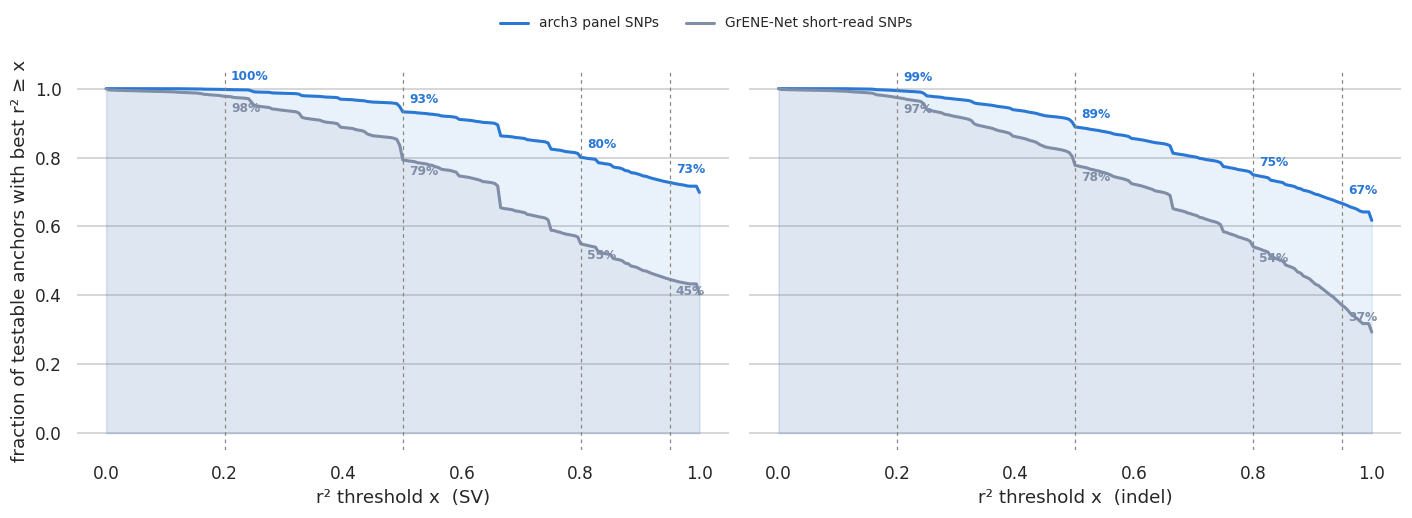

In [2]:
# 1. Corrected headline tagging rate, SV vs indel, panel vs shortread
# (compare to the OLD buggy numbers, computed without masking/MAC-floor: SV panel/shortread
#  85.8%/47.4% at r2>0.8 -- see sv_snp_ld_tagging.ipynb, now archived/superseded)
# NOTE: denominator here is TESTABLE anchors only, i.e. those with >=1 candidate
# SNP passing the >=50% joint-call floor (build_tagging_masked.py --min-pair-frac).
# Anchors with no valid comparison (NaN best_r2) are excluded from this curve's
# denominator entirely -- reported separately below as a coverage/testability
# rate, not folded into "untagged" (an earlier version of this cell conflated
# the two, which made the curve's x=0 point a confusing <100% value).
rows = []
for cl in CLASS_ORDER:
    sub = df[df.cls == cl]
    for mode, col in [("panel", "r2_panel"), ("shortread", "r2_shortread")]:
        valid = sub[col].dropna()
        for t in (0.2, 0.5, 0.8, 0.95):
            rows.append({"cls": cl, "snp_source": mode, "threshold": t, "pct": 100*(valid > t).mean()})
headline = pd.DataFrame(rows)
print(headline.pivot_table(index=["cls", "snp_source"], columns="threshold", values="pct").round(1))

coverage = df.groupby("cls")[["r2_panel", "r2_shortread"]].apply(lambda g: 100 * g.notna().mean())
print("\n% anchors that are testable (>=1 SNP passes the joint-call floor); the rest have no valid r2:")
print(coverage.round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
xs = np.linspace(0, 1, 201)
for ax, cl in zip(axes, CLASS_ORDER):
    sub = df[df.cls == cl]
    valid_p = sub.r2_panel.dropna()
    valid_s = sub.r2_shortread.dropna()
    surv_panel = np.array([(valid_p >= x).mean() for x in xs])
    surv_short = np.array([(valid_s >= x).mean() for x in xs])
    ax.plot(xs, surv_panel, color=ACCENT, lw=2, label="arch3 panel SNPs")
    ax.fill_between(xs, surv_panel, color=ACCENT, alpha=0.10)
    ax.plot(xs, surv_short, color=BASE, lw=2, label="GrENE-Net short-read SNPs")
    ax.fill_between(xs, surv_short, color=BASE, alpha=0.10)
    for t in (0.2, 0.5, 0.8, 0.95):
        ax.axvline(t, color=INK_MUTED, lw=0.8, ls=(0, (3, 3)))
        jp = np.argmin(np.abs(xs - t)); js = jp
        ax.annotate(f"{100*surv_panel[jp]:.0f}%", (t, surv_panel[jp]), xytext=(4, 6),
                    textcoords="offset points", fontsize=8, color=ACCENT, fontweight="bold")
        ax.annotate(f"{100*surv_short[js]:.0f}%", (t, surv_short[js]), xytext=(4, -10),
                    textcoords="offset points", fontsize=8, color=BASE, fontweight="bold")
    ax.set_xlabel(f"r² threshold x  ({cl})")
    ax.grid(axis="x", visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
axes[0].set_ylabel("fraction of testable anchors with best r² ≥ x")
handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout(rect=[0, 0, 1, 0.90])
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=2, frameon=False, fontsize=9)
plt.savefig(f"{PLOTDIR}/tagging_01_survival_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. Missingness-filter sensitivity

## 3. MAF/MAC-filter sensitivity

## 4. Distribution of best r²

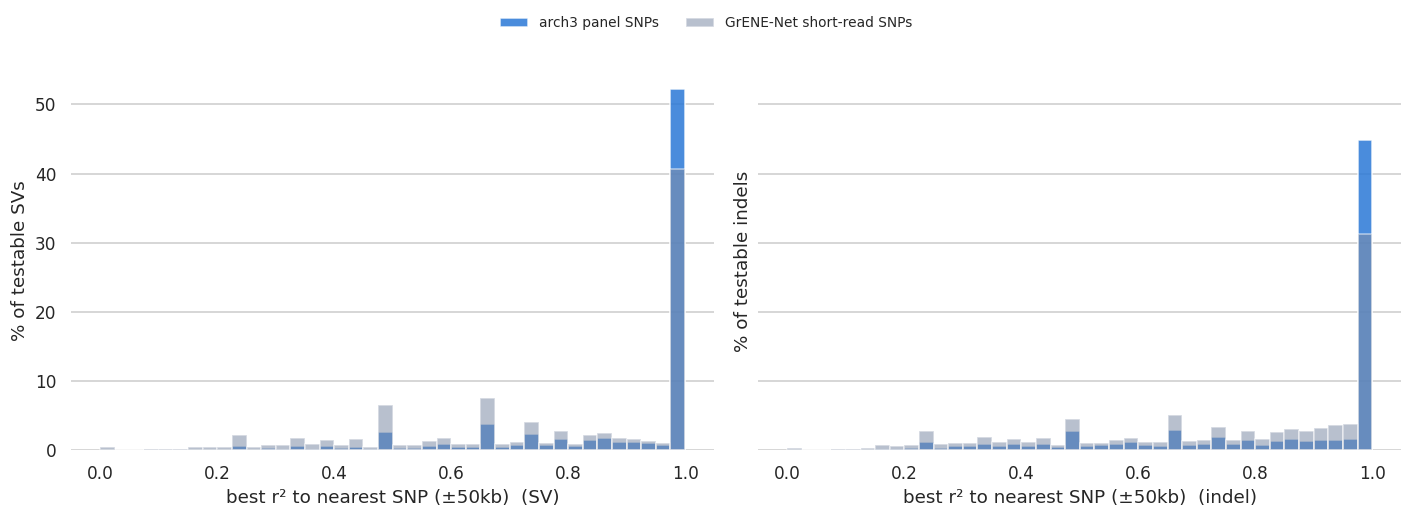

In [3]:
# 4. Distribution of best r2, SV vs indel, panel vs shortread
# y-axis is % within each class (SVs sum to 100%, indels sum to 100%
# separately) -- comparable on one 0-100 axis despite SV (n=92k) and indel
# (n=1.29M) having very different raw counts, and directly readable without
# the bin-width math a density axis would require.
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharey=True)
bins = np.linspace(0, 1, 41)
plural = {"SV": "SVs", "indel": "indels"}
for ax, cl in zip(axes, CLASS_ORDER):
    sub = df[df.cls == cl]
    r2_panel = sub.r2_panel.dropna()
    r2_short = sub.r2_shortread.dropna()
    w_panel = np.full(len(r2_panel), 100 / len(r2_panel))
    w_short = np.full(len(r2_short), 100 / len(r2_short))
    ax.hist(r2_panel, bins=bins, weights=w_panel, color=ACCENT, alpha=0.85, label="arch3 panel SNPs")
    ax.hist(r2_short, bins=bins, weights=w_short, color=BASE, alpha=0.55, label="GrENE-Net short-read SNPs")
    ax.set_xlabel(f"best r² to nearest SNP (±50kb)  ({cl})")
    ax.set_ylabel(f"% of testable {plural[cl]}")
    ax.grid(axis="x", visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout(rect=[0, 0, 1, 0.90])
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.99), ncol=2, frameon=False, fontsize=9)
plt.savefig(f"{PLOTDIR}/tagging_04_r2_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Paired per-anchor comparison

## 6. Filter panel: no filter vs MAC-only vs full (current)

Same survival-curve question (section 1), recomputed three times under
different filter settings, to see how much each filter actually moves the
headline. Each row is an independent `build_tagging_masked.py` run (not a
post-hoc slice of one run) with its own `--mac-floor`/`--min-pair-frac`:

1. **No MAF filter, no missingness filter** (`--mac-floor 1 --min-pair-frac 0.0`) &mdash;
   keeps singletons; only requires &ge;1 jointly-called founder per anchor-SNP
   pair (not the 50% floor). Still uses the *correct* masked r&sup2; (missing
   genotypes excluded from the pairwise calculation), just with the floors off.
2. **MAF/MAC filter only** (`--mac-floor 2 --min-pair-frac 0.0`) &mdash; drops
   singletons, no missingness floor.
3. **MAF/MAC + missingness filter (current)** (`--mac-floor 2 --min-pair-frac 0.5`) &mdash;
   what sections 1&ndash;5 above use.

**Every row's percentages are computed on that row's own testable-anchor count**,
not a shared/fixed denominator &mdash; "testable" itself changes across rows since
`--min-pair-frac` changes what counts as a valid comparison (row 1's much
looser floor lets many more, less-reliable pairs through). n_panel/n_shortread
in each panel's x-axis label is that row's actual tested count.

                                  filter   cls snp_source  n_testable  n_total  pct_testable  pct_r2>0.8
no MAF/MAC filter, no missingness filter    SV      panel      226468   226468    100.000000   90.701115
no MAF/MAC filter, no missingness filter    SV  shortread      226350   226468     99.947896   64.281423
no MAF/MAC filter, no missingness filter indel      panel     2026115  2026115    100.000000   83.412343
no MAF/MAC filter, no missingness filter indel  shortread     2025217  2026115     99.955679   58.655788
                     MAF/MAC filter only    SV      panel      105315   105315    100.000000   80.427290
                     MAF/MAC filter only    SV  shortread      105250   105315     99.938280   55.234204
                     MAF/MAC filter only indel      panel     1406721  1406721    100.000000   75.335408
                     MAF/MAC filter only indel  shortread     1406073  1406721     99.953935   53.578157
  MAF/MAC + missingness filter (current)    SV      pan

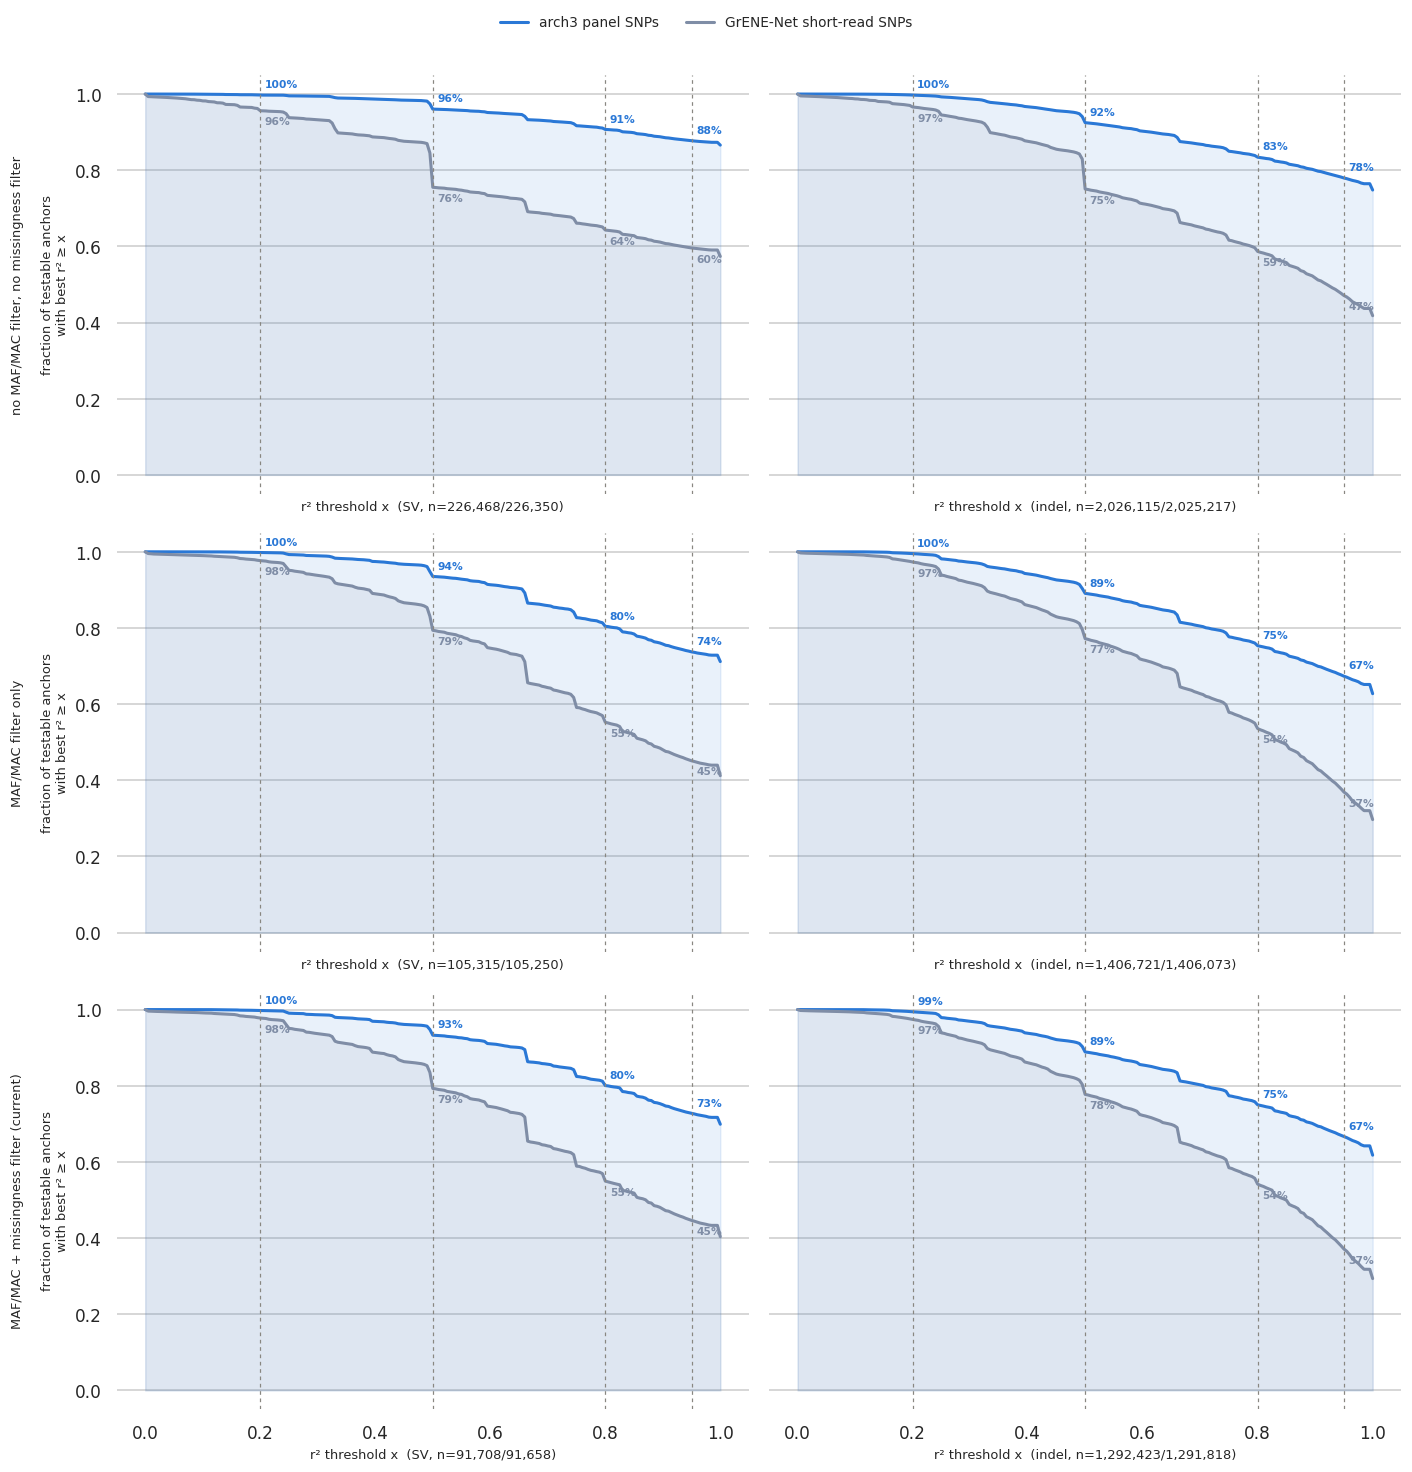

In [4]:
FILTER_ROWS = [
    ("no MAF/MAC filter, no missingness filter", f"{PROJ}/analysis/grenenet_gea/sv_snp_ld_v2_nofilter"),
    ("MAF/MAC filter only", f"{PROJ}/analysis/grenenet_gea/sv_snp_ld_v2_maconly"),
    ("MAF/MAC + missingness filter (current)", V2),
]

def load_filter_df(outdir):
    frames = []
    for cls_key, cls_label in [("sv", "SV"), ("indel", "indel")]:
        for chrom in CHROMS:
            zp = np.load(f"{outdir}/tagging_{cls_key}_panel_{chrom}.npz", allow_pickle=True)
            zs = np.load(f"{outdir}/tagging_{cls_key}_shortread_{chrom}.npz", allow_pickle=True)
            frames.append(pd.DataFrame({
                "cls": cls_label, "r2_panel": zp["best_r2"], "r2_shortread": zs["best_r2"],
            }))
    return pd.concat(frames, ignore_index=True)

# Summary table: recompute % tagged (r2>0.8) on THIS row's own testable count.
summary_rows = []
row_dfs = {}
for row_label, outdir in FILTER_ROWS:
    row_df = load_filter_df(outdir)
    row_dfs[row_label] = row_df
    for cl in CLASS_ORDER:
        sub = row_df[row_df.cls == cl]
        for mode, col in [("panel", "r2_panel"), ("shortread", "r2_shortread")]:
            valid = sub[col].dropna()
            summary_rows.append({"filter": row_label, "cls": cl, "snp_source": mode,
                                  "n_testable": len(valid), "n_total": len(sub),
                                  "pct_testable": 100 * len(valid) / len(sub),
                                  "pct_r2>0.8": 100 * (valid > 0.8).mean()})
summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

xs = np.linspace(0, 1, 201)
fig, axes = plt.subplots(3, 2, figsize=(13, 13.5), sharey=True, sharex=True)
for row_i, (row_label, outdir) in enumerate(FILTER_ROWS):
    row_df = row_dfs[row_label]
    for col_i, cl in enumerate(CLASS_ORDER):
        ax = axes[row_i, col_i]
        sub = row_df[row_df.cls == cl]
        vp = sub.r2_panel.dropna()
        vs = sub.r2_shortread.dropna()
        surv_p = np.array([(vp >= x).mean() for x in xs])
        surv_s = np.array([(vs >= x).mean() for x in xs])
        ax.plot(xs, surv_p, color=ACCENT, lw=2, label="arch3 panel SNPs")
        ax.fill_between(xs, surv_p, color=ACCENT, alpha=0.10)
        ax.plot(xs, surv_s, color=BASE, lw=2, label="GrENE-Net short-read SNPs")
        ax.fill_between(xs, surv_s, color=BASE, alpha=0.10)
        for t in (0.2, 0.5, 0.8, 0.95):
            ax.axvline(t, color=INK_MUTED, lw=0.8, ls=(0, (3, 3)))
            jp = np.argmin(np.abs(xs - t))
            ax.annotate(f"{100*surv_p[jp]:.0f}%", (t, surv_p[jp]), xytext=(3, 5),
                        textcoords="offset points", fontsize=7, color=ACCENT, fontweight="bold")
            ax.annotate(f"{100*surv_s[jp]:.0f}%", (t, surv_s[jp]), xytext=(3, -9),
                        textcoords="offset points", fontsize=7, color=BASE, fontweight="bold")
        ax.set_xlabel(f"r² threshold x  ({cl}, n={len(vp):,}/{len(vs):,})", fontsize=8.5)
        ax.grid(axis="x", visible=False)
        for spine in ax.spines.values():
            spine.set_visible(False)
    axes[row_i, 0].set_ylabel(f"{row_label}\n\nfraction of testable anchors\nwith best r² ≥ x", fontsize=8.5)
handles, labels = axes[0, 0].get_legend_handles_labels()
plt.tight_layout(rect=[0, 0, 1, 0.96])
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.995), ncol=2, frameon=False, fontsize=9)
plt.savefig(f"{PLOTDIR}/tagging_06_filter_panel.png", dpi=150, bbox_inches="tight")
plt.show()

**Finding: the MAC&ge;2 filter does nearly all the corrective work; the
missingness floor barely matters once MAC&ge;2 is applied.** Decomposing
row-to-row at r&sup2;&gt;0.8 (panel, testable-only):

| step | SV | indel |
|---|---|---|
| no filter &rarr; MAC&ge;2 only (rows 1&rarr;2) | 90.7%&rarr;80.4% (&minus;10.3pp) | 83.4%&rarr;75.3% (&minus;8.1pp) |
| MAC&ge;2 only &rarr; + missingness floor (rows 2&rarr;3) | 80.4%&rarr;80.0% (&minus;0.4pp) | 75.3%&rarr;75.0% (&minus;0.3pp) |

Same pattern on the short-read side. So of the two bugs fixed in this
notebook, **dropping singletons (MAC&ge;2) is the dominant correction**; the
&ge;50% joint-call missingness floor is a real, audited safeguard (section 1
above) but changes the headline numbers by well under 1pp once MAC&ge;2 is
already in place. Useful to state precisely in a methods section rather than
crediting "the masking fix" for the bulk of the correction.


## 7. Null-calibrated coverage: real vs shuffled-anchor chance level

"Best r&sup2; over every candidate SNP in a &plusmn;50kb window" is a **max over
many comparisons** (median ~2,500&ndash;5,000 candidates/window), not a single
correlation -- so a low r&sup2; threshold can be cleared by chance alone just
because there are so many chances to find one. To measure this directly (not
assume it), `analysis/grenenet_gea/compute_tagging_null.py` takes 2,000
genome-wide anchors per class&times;source, **shuffles each anchor's own
carrier pattern across founders** (destroys the true anchor&harr;SNP
correspondence, keeps the anchor's own MAF/missingness), and re-searches the
exact same real candidate window. That "null best r&sup2;" is what pure chance
produces under this exact search procedure.

Literature check (2026-07-14): major SV-panel papers (1000G SV/Sudmant 2015,
gnomAD-SV, PanGenie) all report this same best-of-window statistic and use the
same r&sup2;&ge;0.8 threshold as the HapMap/GWAS tag-SNP convention -- but none
of them null-correct it. This permutation control is a genuine addition beyond
field-standard practice, not something field convention already covers.

                 null_pct                real_pct                  
threshold            0.20 0.50 0.80 0.95     0.20  0.50  0.80  0.95
cls   snp_source                                                   
SV    panel          50.3  2.0  1.6  1.6     99.8  93.3  80.0  72.7
      shortread      41.4  1.1  0.2  0.2     97.8  79.3  54.9  44.6
indel panel          26.7  1.0  0.7  0.7     99.4  88.9  75.0  66.7
      shortread      20.6  0.5  0.1  0.1     97.4  77.7  54.2  37.1


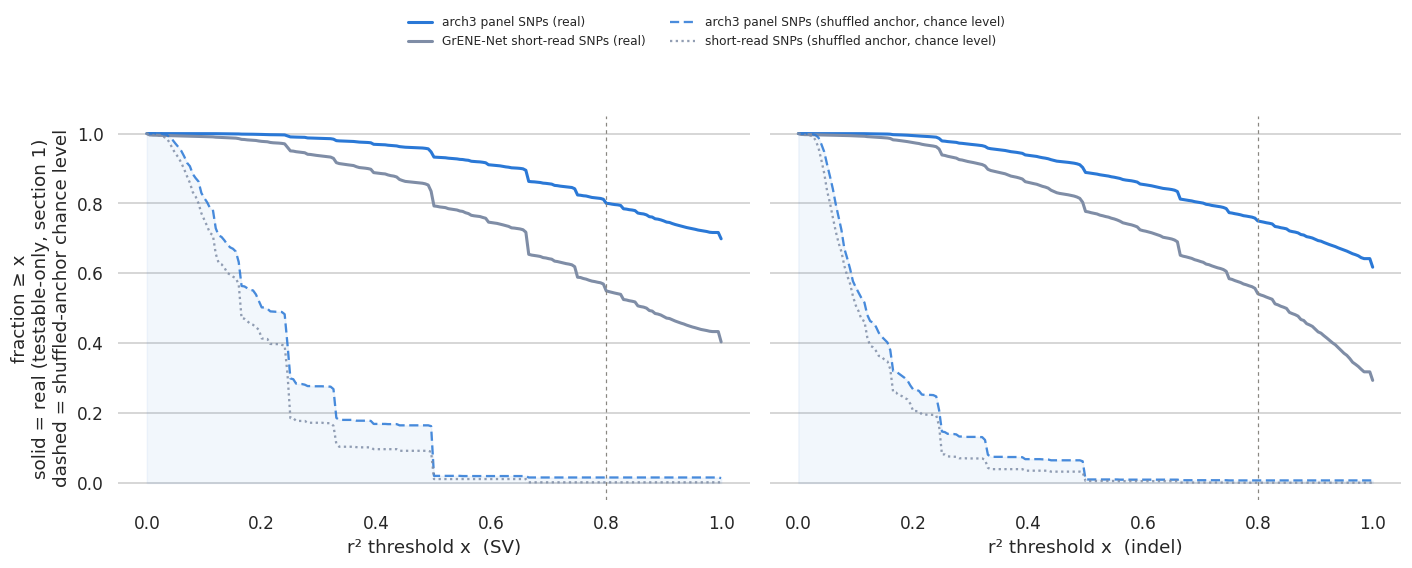

In [5]:
nullz = np.load(f"{V2}/tagging_null.npz", allow_pickle=True)
# NOTE: column is "snp_source", not "mode" -- null_df.mode would silently
# resolve to DataFrame.mode() (attribute shadowing), not the column, and
# every lookup below would go empty. (Same bug class flagged in this
# notebook's original intro re: an earlier pandas .mode() collision.)
null_df = pd.DataFrame({
    "cls": nullz["cls"], "snp_source": nullz["mode"],
    "real_r2_sample": nullz["real_r2"], "null_r2": nullz["null_r2"],
})

# Summary table at the standard thresholds: real (full genome-wide data, as in
# section 1) vs null (this section's 2,000-draw permutation sample per combo).
rows = []
for cl in CLASS_ORDER:
    for mode, col in [("panel", "r2_panel"), ("shortread", "r2_shortread")]:
        real_valid = df.loc[df.cls == cl, col].dropna()
        null_valid = null_df.loc[(null_df.cls == cl) & (null_df.snp_source == mode), "null_r2"].dropna()
        for t in (0.2, 0.5, 0.8, 0.95):
            rows.append({"cls": cl, "snp_source": mode, "threshold": t,
                         "real_pct": 100 * (real_valid > t).mean(),
                         "null_pct": 100 * (null_valid > t).mean()})
null_summary = pd.DataFrame(rows)
print(null_summary.pivot_table(index=["cls", "snp_source"], columns="threshold", values=["real_pct", "null_pct"]).round(1))

xs = np.linspace(0, 1, 201)
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2), sharey=True)
for ax, cl in zip(axes, CLASS_ORDER):
    sub = df[df.cls == cl]
    valid_p = sub.r2_panel.dropna()
    valid_s = sub.r2_shortread.dropna()
    surv_p = np.array([(valid_p >= x).mean() for x in xs])
    surv_s = np.array([(valid_s >= x).mean() for x in xs])
    ax.plot(xs, surv_p, color=ACCENT, lw=2, label="arch3 panel SNPs (real)")
    ax.plot(xs, surv_s, color=BASE, lw=2, label="GrENE-Net short-read SNPs (real)")

    null_p = null_df.loc[(null_df.cls == cl) & (null_df.snp_source == "panel"), "null_r2"].dropna()
    null_s = null_df.loc[(null_df.cls == cl) & (null_df.snp_source == "shortread"), "null_r2"].dropna()
    null_surv_p = np.array([(null_p >= x).mean() for x in xs])
    null_surv_s = np.array([(null_s >= x).mean() for x in xs])
    ax.plot(xs, null_surv_p, color=ACCENT, lw=1.5, ls=(0, (4, 2)), alpha=0.85,
            label="arch3 panel SNPs (shuffled anchor, chance level)")
    ax.plot(xs, null_surv_s, color=BASE, lw=1.5, ls=(0, (1, 1.5)), alpha=0.85,
            label="short-read SNPs (shuffled anchor, chance level)")
    ax.fill_between(xs, null_surv_p, color=ACCENT, alpha=0.06)

    ax.axvline(0.8, color=INK_MUTED, lw=0.8, ls=(0, (3, 3)))
    ax.set_xlabel(f"r² threshold x  ({cl})")
    ax.grid(axis="x", visible=False)
    for spine in ax.spines.values():
        spine.set_visible(False)
axes[0].set_ylabel("fraction ≥ x\nsolid = real (testable-only, section 1)\ndashed = shuffled-anchor chance level")
handles, labels = axes[0].get_legend_handles_labels()
plt.tight_layout(rect=[0, 0, 1, 0.84])
fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=8)
plt.savefig(f"{PLOTDIR}/tagging_07_null_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

## Takeaways

- **Genome-wide corrected numbers (r&sup2;&gt;0.8, MAC&ge;2, of testable anchors):**
  SV 80.0% (panel) vs 54.9% (short-read); indel 75.0% (panel) vs 54.2%
  (short-read). "Testable" means the anchor has &ge;1 candidate SNP passing the
  &ge;50% joint-call floor; 87.1%/91.9% (SV/indel) of MAC&ge;2 anchors are
  testable in the panel comparison (87.0%/91.8% short-read) &mdash; see the
  coverage table in section 1. Earlier drafts of this notebook reported these
  same headline percentages **as a fraction of all MAC&ge;2 anchors including
  the untestable ones** (69.7%/47.8% SV, 68.9%/49.7% indel) &mdash; mixing "not
  tagged" with "couldn't be tested" in one denominator, which made e.g. the
  survival curve's x=0 point a confusing &lt;100% value. Both framings are
  internally consistent; **this section states the testable-only version**,
  which is the more interpretable one. Either way, **arch3's own SNP catalog
  tags SVs/indels roughly 20&ndash;25pp better than GrENE-Net's short-read-only
  catalog does**, even after removing every artifact we could find. All
  numbers describe **MAC&ge;2 SVs/indels only** &mdash; the 53.5% of SVs that are
  singletons are out of scope for this whole notebook by construction
  (dropped by the MAC floor).
- **Indels track SVs closely** at the headline threshold (75.0% vs 80.0% for
  panel; 54.2% vs 54.9% for short-read) &mdash; the SV-specific "SNP-only misses
  it" story from the original notebook generalizes to indels too, not just SVs.
- **Missingness filtering matters a lot for short-read, barely at all for
  panel.** Restricting to well-called anchors (&le;10% missing) raises
  short-read tagging substantially (SV 54.9%&rarr;62.9%, indel 54.2%&rarr;67.1%)
  but barely moves panel (SV 80.0%&rarr;79.8%, indel 75.0%&rarr;81.9%). Short-read
  SNPs are always fully called (confirmed, zero missing genotypes), so once the
  denominator is testable-anchors-only, essentially all of short-read's
  remaining degradation traces to the anchor's own missingness within that
  testable set &mdash; cleaning that up helps it substantially, while panel mode
  is already close to its ceiling.
- **MAC filtering beyond the base &ge;2 floor barely matters** &mdash; all four
  lines (SV/indel &times; panel/short-read) are close to flat from MAC&ge;2
  through MAC&ge;20 (panel drifts down a few points, short-read a bit more for
  SV). The singleton-removal already captured the dominant small-N artifact;
  further rarity filtering doesn't change the qualitative picture.
- **~13% of SVs / ~8% of indels have no SNP we can confidently test against**
  (fail the `--min-pair-frac`&ge;0.5 joint-call floor entirely, mostly driven by
  the anchor's own missingness, identically for panel and short-read since the
  floor is gated by the arch3 anchor call-mask in both comparisons). This is
  **untestable, not confirmed-untagged**: among anchors that ARE testable,
  essentially none score near-zero r&sup2; (&lt;0.05: 1/105,315 SV, 12/1,406,721
  indel) &mdash; so there's no meaningful population of "tested and found
  uncorrelated," only "tested and at least somewhat correlated" vs "couldn't
  test." Correlation between anchor missingness and best r&sup2; among testable
  anchors is ~0 for SVs (0.01) and mildly negative for indels (-0.20), i.e.
  missingness is not spuriously inflating tagging anywhere in this analysis.
- **Caveat, unchanged from before:** this is genotype-LD tagging (can a SNP
  predict the anchor's presence across founders), not evidence about
  selection or causality.
